In [ ]:
%pip install pandas matplotlib
# pip install -e "D:\code-repo\Chomo\chronos-forecasting"
# or pip install chronos-forecasting

%pip install torch torchvision --index-url https://download.pytorch.org/whl/cu129

In [1]:
import os
import sys
print(sys.path)

# Use only 1 GPU if available
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from chronos import BaseChronosPipeline, Chronos2Pipeline
import chronos as chronos
print ("Chronos version:", chronos.__version__)

['C:\\Users\\alex\\AppData\\Local\\Programs\\Python\\Python313\\python313.zip', 'C:\\Users\\alex\\AppData\\Local\\Programs\\Python\\Python313\\DLLs', 'C:\\Users\\alex\\AppData\\Local\\Programs\\Python\\Python313\\Lib', 'C:\\Users\\alex\\AppData\\Local\\Programs\\Python\\Python313', 'd:\\code-repo\\Chomo\\chronos-forecasting\\env', '', 'd:\\code-repo\\Chomo\\chronos-forecasting\\env\\Lib\\site-packages', 'D:\\code-repo\\Chomo\\chronos-forecasting\\src']


d:\code-repo\Chomo\chronos-forecasting\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Chronos version: 2.0.0


In [2]:
# Load the Chronos-2 pipeline
# GPU recommended for faster inference, but CPU is also supported
pipeline: Chronos2Pipeline = BaseChronosPipeline.from_pretrained("amazon/chronos-2", device_map="cuda")

# ETT-small Dataset

all_preds shape: (1280, 9)


,item_id,date,target_name,predictions,0.2,0.5,0.8,window_start_idx,global_idx
0,1,2017-08-21 16:00:00,OT,19.422813,18.939569,19.422813,19.852427,10000,10000
1,1,2017-08-21 17:00:00,OT,18.988483,18.395527,18.988483,19.525730,10000,10001
2,1,2017-08-21 18:00:00,OT,18.166115,17.465021,18.166115,18.738529,10000,10002
3,1,2017-08-21 19:00:00,OT,17.292398,16.504629,17.292398,17.937355,10000,10003
4,1,2017-08-21 20:00:00,OT,16.832245,16.102221,16.832245,17.495571,10000,10004
5,1,2017-08-21 21:00:00,OT,16.582937,15.833670,16.582937,17.218639,10000,10005
6,1,2017-08-21 22:00:00,OT,16.464399,15.676669,16.464399,17.130190,10000,10006
7,1,2017-08-21 23:00:00,OT,16.249352,15.460938,16.249352,16.918093,10000,10007
8,1,2017-08-22 00:00:00,OT,16.152349,15.369294,16.152349,16.835699,10000,10008
9,1,2017-08-22 01:00:00,OT,16.060740,15.274683,16.060740,16.723444,10000,10009


Position -> future_targets original [(0, '2017-08-21 16:00:00'), (1, '2017-08-21 17:00:00'), (2, '2017-08-21 18:00:00'), (3, '2017-08-21 19:00:00'), (4, '2017-08-21 20:00:00'), (5, '2017-08-21 21:00:00'), (6, '2017-08-21 22:00:00'), (7, '2017-08-21 23:00:00'), (8, '2017-08-22 00:00:00'), (9, '2017-08-22 01:00:00'), (10, '2017-08-22 02:00:00'), (11, '2017-08-22 03:00:00'), (12, '2017-08-22 04:00:00'), (13, '2017-08-22 05:00:00'), (14, '2017-08-22 06:00:00'), (15, '2017-08-22 07:00:00'), (16, '2017-08-22 08:00:00'), (17, '2017-08-22 09:00:00'), (18, '2017-08-22 10:00:00'), (19, '2017-08-22 11:00:00'), (20, '2017-08-22 12:00:00'), (21, '2017-08-22 13:00:00'), (22, '2017-08-22 14:00:00'), (23, '2017-08-22 15:00:00'), (24, '2017-08-22 16:00:00'), (25, '2017-08-22 17:00:00'), (26, '2017-08-22 18:00:00'), (27, '2017-08-22 19:00:00'), (28, '2017-08-22 20:00:00'), (29, '2017-08-22 21:00:00'), (30, '2017-08-22 22:00:00'), (31, '2017-08-22 23:00:00'), (32, '2017-08-23 00:00:00'), (33, '2017-08-23

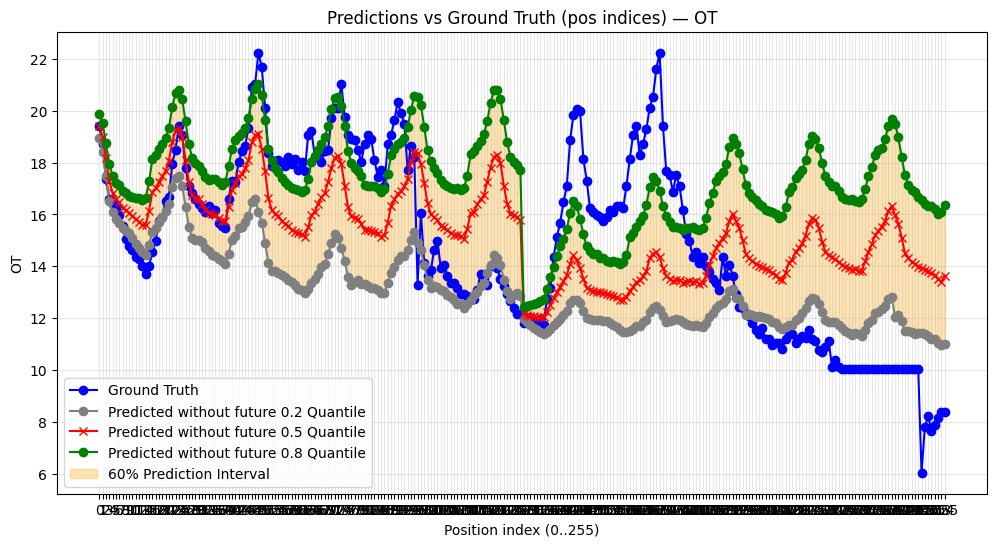

In [25]:
# Load raw data
context_df = pd.read_csv("./rawData/long_term_forecast/ETT-small/ETTh1.csv")

# Set column names
id_column = "item_id"
timestamp_column = "date"
return_targets = ["OT"]
quantile_levels=[0.2, 0.5, 0.8]
prediction_length = 128

# Set the test span indexes
test_start_idx = 10000  # starting index of the test span
test_end_idx = test_start_idx + 10*prediction_length    # ending index of the test span
future_targets = context_df.iloc[test_start_idx : test_end_idx].reset_index(drop=True).copy()

# Add a id column if not present, use same id as they are just in a same task
if id_column not in context_df.columns:
    context_df[id_column] = 1

# ---------------------- Step 1: predict without future covariates ------------------------------
# loop for multiple windows prediction
predictions_list = []
end_limit = min(test_end_idx, len(context_df) - prediction_length + 1)
for start in range(test_start_idx, end_limit, prediction_length):
    # prepare input data for the current window
    context_input_win = context_df.iloc[:start].reset_index(drop=True).copy()

    # make prediction
    pred_win = pipeline.predict_df(
        context_input_win,
        prediction_length=prediction_length,
        quantile_levels=quantile_levels,
        id_column=id_column,
        timestamp_column=timestamp_column,
        target=return_targets,
    ).reset_index(drop=True)

    # add metadata columns to the prediction window
    pred_win['window_start_idx'] = start
    pred_win['global_idx'] = np.arange(start, start + len(pred_win))

    # validate timestamp alignment between prediction and ground truth
    assert len(pred_win) == prediction_length, f"Prediction length mismatch: expected {prediction_length}, got {len(pred_win)}"
    ground_truth_timestamp_slice = context_df.iloc[start : start + prediction_length][timestamp_column].reset_index(drop=True)

    # validate timestamp alignment between prediction and ground truth
    # pred_win's timestamps are in pd.DatetimeIndex format, while ground_truth_timestamp_slice is a pd.Series
    pred_win[timestamp_column] = pd.to_datetime(pred_win[timestamp_column])
    ground_truth_timestamp_slice = pd.to_datetime(ground_truth_timestamp_slice)
    if not pred_win[timestamp_column].equals(ground_truth_timestamp_slice):
        raise ValueError(f"Timestamp mismatch at window starting index {start}")

    predictions_list.append(pred_win)

# combine all window predictions
all_preds = pd.concat(predictions_list, ignore_index=True)

# Optional: sort by global_idx and drop duplicates (in case of overlapping windows or duplicate rows)
all_preds = all_preds.sort_values('global_idx').drop_duplicates(subset=['global_idx']).reset_index(drop=True)

# check the final predictions shape
print("all_preds shape:", all_preds.shape)
display(all_preds.head(10))

# compute the quantile bands between 0.2 and 0.8, float32
all_preds['quantile_band_0.2_0.8'] = (all_preds['0.8'] - all_preds['0.2']).astype(np.float32)


# ---------------------- Visualization ------------------------------
# Plot each return target with median and 0.2/0.8 quantiles
qcols = [f"{q:.1f}" for q in quantile_levels]
n = 2 * prediction_length  # number of points to plot
future_short = future_targets.iloc[:n].copy()
pred_without_future = all_preds.copy().reset_index(drop=True).iloc[:n].copy()

# Create simple positional indices for plotting
x = np.arange(len(future_short))
future_short['pos'] = x
pred_without_future['pos'] = x

# Optional: show mapping from position index to original timestamp for reference
try:
    original_ts = future_short[timestamp_column].astype(str).tolist()
    print('Position -> future_targets original', list(enumerate(original_ts)))
except Exception:
    pass

for target in return_targets:
    # check quantile columns
    for q in qcols:
        if q not in pred_without_future.columns:
            print(f'Quantile column {q} for {target} not found in pred_without_future; available columns: {list(pred_without_future.columns)}')
            continue
            
    plt.figure(figsize=(12, 6))
    plt.title(f'Predictions vs Ground Truth (pos indices) — {target}')
    
    # i) Ground truth (from future_short)
    if target in future_short.columns:
        plt.plot(x, future_short[target].values, label='Ground Truth', color='blue', marker='o')
    else:
        print(f'Warning: target {target} not present in future_targets')

    # ii) Predicted without future quantiles
    plt.plot(x, pred_without_future[qcols[0]].values, label='Predicted without future 0.2 Quantile', color='gray', marker='o')
    plt.plot(x, pred_without_future[qcols[1]].values, label='Predicted without future 0.5 Quantile', color='red', marker='x')
    plt.plot(x, pred_without_future[qcols[2]].values, label='Predicted without future 0.8 Quantile', color='green', marker='o')

    # Prediction interval if quantiles available
    low_col = target + '_0.2'
    high_col = target + '_0.8'
    plt.fill_between(x, pred_without_future[qcols[0]].values, pred_without_future[qcols[2]].values, color='orange', alpha=0.3, label='60% Prediction Interval')

    plt.xlabel('Position index (0..{})'.format(len(x)-1))
    plt.xticks(x)
    plt.ylabel(target)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()



In [41]:
# ---------------------- Step 2: predit with future covariates ------------------------------
# Add a 'quantile_band_0.2_0.8' column to context_input, with all nan values
context_df = pd.read_csv("./rawData/long_term_forecast/ETT-small/ETTh1.csv")
if id_column not in context_df.columns:
    context_df[id_column] = 1

context_df_with_quantile_band = context_df.reset_index(drop=True).copy()
context_df_with_quantile_band['quantile_band_0.2_0.8'] = np.float32(np.nan)

# Set column names
id_column = "item_id"
timestamp_column = "date"
return_targets = ["OT"]
quantile_levels=[0.2, 0.5, 0.8]
prediction_length = 128

# Set the test span indexes
test_start_idx = 10000  # starting index of the test span
test_end_idx = test_start_idx + 10*prediction_length    # ending index of the test span
# future_targets = context_df_with_quantile_band.iloc[test_start_idx : test_end_idx].reset_index(drop=True).copy()

# Add a id column if not present, use same id as they are just in a same task
if id_column not in context_df.columns:
    context_df[id_column] = 1

# loop for multiple windows prediction
predictions_list = []
predictions_with_future_list = []
end_limit = min(test_end_idx, len(context_df) - prediction_length + 1)

for start in range(test_start_idx, end_limit, prediction_length):
    # Step 1. predict without future covariates
    # prepare input data for the current window
    context_input_win = context_df.iloc[:start].reset_index(drop=True).copy()

    # make prediction
    pred_win = pipeline.predict_df(
        context_input_win,
        prediction_length=prediction_length,
        quantile_levels=quantile_levels,
        id_column=id_column,
        timestamp_column=timestamp_column,
        target=return_targets,
    ).reset_index(drop=True)
    # compute the quantile bands between 0.2 and 0.8, float32
    pred_win['quantile_band_0.2_0.8'] = (pred_win['0.8'] - pred_win['0.2']).astype(np.float32)

    # Step 2. predict with future covariates
    # prepare input data for the current window, with quantile_band_0.2_0.8 column
    context_input_with_band = context_df_with_quantile_band.iloc[:start].reset_index(drop=True).copy()
    
    # validate alignment between context_input_with_band and context_input_win
    assert len(context_input_with_band) == len(context_input_win), f"Length mismatch between context_input_with_band and context_input_win at start index {start}"
    if not context_input_with_band[timestamp_column].equals(context_input_win[timestamp_column]):
        raise ValueError(f"Timestamp mismatch between context_input_with_band and context_input_win at start index {start}")

    # build future_df with id column, a timestamp, and 'quantile_band_0.2_0.8'
    future_df_with_band = context_df_with_quantile_band[[id_column, timestamp_column]].copy()
    future_df_with_band = future_df_with_band.iloc[start : start + prediction_length].reset_index(drop=True)

    # validate future_df_with_band alignment with pred_win
    print(f'length of future_df_with_band: {len(future_df_with_band)}, length of pred_win: {len(pred_win)} at start index {start}')
    assert len(future_df_with_band) == len(pred_win), f"Length mismatch between future_df_with_band and pred_win at start index {start}"
    pred_win[timestamp_column] = pd.to_datetime(pred_win[timestamp_column])
    future_df_with_band[timestamp_column] = pd.to_datetime(future_df_with_band[timestamp_column])
    if not future_df_with_band[timestamp_column].equals(pred_win[timestamp_column]):
        raise ValueError(f"Timestamp mismatch between future_df_with_band and pred_win at start index {start}")

    future_df_with_band['quantile_band_0.2_0.8'] = pred_win['quantile_band_0.2_0.8'].reset_index(drop=True).iloc[:prediction_length].values

    # make predictions with future covariates
    pred_df_with_future = pipeline.predict_df(
        df        = context_input_with_band,
        future_df = future_df_with_band,
        prediction_length=prediction_length,
        quantile_levels=quantile_levels,
        id_column=id_column,
        timestamp_column=timestamp_column,
        target=return_targets,
    )

    # add metadata columns to the prediction window
    pred_win['window_start_idx'] = start
    pred_win['global_idx'] = np.arange(start, start + len(pred_win))
    pred_df_with_future['window_start_idx'] = start
    pred_df_with_future['global_idx'] = np.arange(start, start + len(pred_df_with_future))

    # validate timestamp alignment between prediction and ground truth
    assert len(pred_win) == prediction_length, f"Prediction length mismatch: expected {prediction_length}, got {len(pred_win)}"
    assert len(pred_df_with_future) == prediction_length, f"Prediction length mismatch: expected {prediction_length}, got {len(pred_df_with_future)}"
    ground_truth_timestamp_slice = context_df.iloc[start : start + prediction_length][timestamp_column].reset_index(drop=True)

    # validate timestamp alignment between prediction and ground truth
    ground_truth_timestamp_slice = pd.to_datetime(ground_truth_timestamp_slice)
    if not pred_win[timestamp_column].equals(ground_truth_timestamp_slice):
        raise ValueError(f"Timestamp mismatch at window starting index {start}")
    
    pred_df_with_future[timestamp_column] = pd.to_datetime(pred_df_with_future[timestamp_column])
    if not pred_df_with_future[timestamp_column].equals(ground_truth_timestamp_slice):
        raise ValueError(f"Timestamp mismatch at window starting index {start}")

    predictions_list.append(pred_win)
    predictions_with_future_list.append(pred_df_with_future)

# combine all window predictions
all_preds = pd.concat(predictions_list, ignore_index=True)
all_preds_with_future = pd.concat(predictions_with_future_list, ignore_index=True)

# # Optional: sort by global_idx and drop duplicates (in case of overlapping windows or duplicate rows)
# all_preds = all_preds.sort_values('global_idx').drop_duplicates(subset=['global_idx']).reset_index(drop=True)
# all_preds_with_future = all_preds_with_future.sort_values('global_idx').drop_duplicates(subset=['global_idx']).reset_index(drop=True)

# check the final predictions shape
print("all_preds shape:", all_preds.shape)
print("all_preds_with_future shape:", all_preds_with_future.shape)
display(all_preds.head(10))
display(all_preds_with_future.head(10))

# compute the quantile bands between 0.2 and 0.8, float32
all_preds['quantile_band_0.2_0.8'] = (all_preds['0.8'] - all_preds['0.2']).astype(np.float32)
all_preds_with_future['quantile_band_0.2_0.8'] = (all_preds_with_future['0.8'] - all_preds_with_future['0.2']).astype(np.float32)

length of future_df_with_band: 128, length of pred_win: 128 at start index 10000
length of future_df_with_band: 128, length of pred_win: 128 at start index 10128
length of future_df_with_band: 128, length of pred_win: 128 at start index 10256
length of future_df_with_band: 128, length of pred_win: 128 at start index 10384
length of future_df_with_band: 128, length of pred_win: 128 at start index 10512
length of future_df_with_band: 128, length of pred_win: 128 at start index 10640
length of future_df_with_band: 128, length of pred_win: 128 at start index 10768
length of future_df_with_band: 128, length of pred_win: 128 at start index 10896
length of future_df_with_band: 128, length of pred_win: 128 at start index 11024
length of future_df_with_band: 128, length of pred_win: 128 at start index 11152
all_preds shape: (1280, 10)
all_preds_with_future shape: (1280, 9)


,item_id,date,target_name,predictions,0.2,0.5,0.8,quantile_band_0.2_0.8,window_start_idx,global_idx
0,1,2017-08-21 16:00:00,OT,19.422813,18.939569,19.422813,19.852427,0.912857,10000,10000
1,1,2017-08-21 17:00:00,OT,18.988483,18.395527,18.988483,19.525730,1.130203,10000,10001
2,1,2017-08-21 18:00:00,OT,18.166115,17.465021,18.166115,18.738529,1.273508,10000,10002
3,1,2017-08-21 19:00:00,OT,17.292398,16.504629,17.292398,17.937355,1.432726,10000,10003
4,1,2017-08-21 20:00:00,OT,16.832245,16.102221,16.832245,17.495571,1.393351,10000,10004
5,1,2017-08-21 21:00:00,OT,16.582937,15.833670,16.582937,17.218639,1.384970,10000,10005
6,1,2017-08-21 22:00:00,OT,16.464399,15.676669,16.464399,17.130190,1.453521,10000,10006
7,1,2017-08-21 23:00:00,OT,16.249352,15.460938,16.249352,16.918093,1.457154,10000,10007
8,1,2017-08-22 00:00:00,OT,16.152349,15.369294,16.152349,16.835699,1.466405,10000,10008
9,1,2017-08-22 01:00:00,OT,16.060740,15.274683,16.060740,16.723444,1.448761,10000,10009


,item_id,date,target_name,predictions,0.2,0.5,0.8,window_start_idx,global_idx
0,1,2017-08-21 16:00:00,OT,19.358881,18.833195,19.358881,19.811018,10000,10000
1,1,2017-08-21 17:00:00,OT,18.915241,18.294746,18.915241,19.467262,10000,10001
2,1,2017-08-21 18:00:00,OT,18.127104,17.417915,18.127104,18.708599,10000,10002
3,1,2017-08-21 19:00:00,OT,17.258245,16.475000,17.258245,17.908112,10000,10003
4,1,2017-08-21 20:00:00,OT,16.789434,16.086679,16.789434,17.438042,10000,10004
5,1,2017-08-21 21:00:00,OT,16.554995,15.839895,16.554995,17.166876,10000,10005
6,1,2017-08-21 22:00:00,OT,16.424025,15.634716,16.424025,17.094707,10000,10006
7,1,2017-08-21 23:00:00,OT,16.200645,15.395048,16.200645,16.880844,10000,10007
8,1,2017-08-22 00:00:00,OT,16.098318,15.299034,16.098318,16.788839,10000,10008
9,1,2017-08-22 01:00:00,OT,15.999098,15.201902,15.999098,16.662920,10000,10009


Position -> future_targets original [(0, '2017-08-21 16:00:00'), (1, '2017-08-21 17:00:00'), (2, '2017-08-21 18:00:00'), (3, '2017-08-21 19:00:00'), (4, '2017-08-21 20:00:00'), (5, '2017-08-21 21:00:00'), (6, '2017-08-21 22:00:00'), (7, '2017-08-21 23:00:00'), (8, '2017-08-22 00:00:00'), (9, '2017-08-22 01:00:00'), (10, '2017-08-22 02:00:00'), (11, '2017-08-22 03:00:00'), (12, '2017-08-22 04:00:00'), (13, '2017-08-22 05:00:00'), (14, '2017-08-22 06:00:00'), (15, '2017-08-22 07:00:00'), (16, '2017-08-22 08:00:00'), (17, '2017-08-22 09:00:00'), (18, '2017-08-22 10:00:00'), (19, '2017-08-22 11:00:00'), (20, '2017-08-22 12:00:00'), (21, '2017-08-22 13:00:00'), (22, '2017-08-22 14:00:00'), (23, '2017-08-22 15:00:00'), (24, '2017-08-22 16:00:00'), (25, '2017-08-22 17:00:00'), (26, '2017-08-22 18:00:00'), (27, '2017-08-22 19:00:00'), (28, '2017-08-22 20:00:00'), (29, '2017-08-22 21:00:00'), (30, '2017-08-22 22:00:00'), (31, '2017-08-22 23:00:00'), (32, '2017-08-23 00:00:00'), (33, '2017-08-23

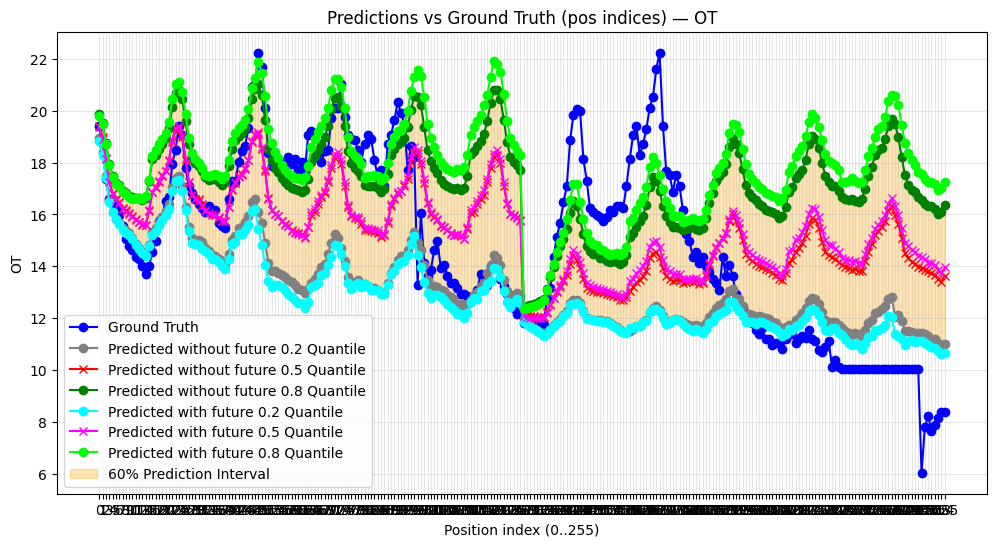

In [40]:
# ---------------------- Visualization ------------------------------
# Plot each return target with median and 0.2/0.8 quantiles
qcols = [f"{q:.1f}" for q in quantile_levels]
n = 2 * prediction_length  # number of points to plot
future_short = future_targets.iloc[:n].copy()
pred_without_future = all_preds.copy().reset_index(drop=True).iloc[:n].copy()
pred_with_future = all_preds_with_future.copy().reset_index(drop=True).iloc[:n].copy()

# Create simple positional indices for plotting
x = np.arange(len(future_short))
future_short['pos'] = x
pred_without_future['pos'] = x
pred_with_future['pos'] = x

# Optional: show mapping from position index to original timestamp for reference
try:
    original_ts = future_short[timestamp_column].astype(str).tolist()
    print('Position -> future_targets original', list(enumerate(original_ts)))
except Exception:
    pass

for target in return_targets:
    # check quantile columns
    for q in qcols:
        if q not in pred_without_future.columns:
            print(f'Quantile column {q} for {target} not found in pred_without_future; available columns: {list(pred_without_future.columns)}')
            continue
            
    plt.figure(figsize=(12, 6))
    plt.title(f'Predictions vs Ground Truth (pos indices) — {target}')
    
    # i) Ground truth (from future_short)
    if target in future_short.columns:
        plt.plot(x, future_short[target].values, label='Ground Truth', color='blue', marker='o')
    else:
        print(f'Warning: target {target} not present in future_targets')

    # ii) Predicted without future quantiles
    plt.plot(x, pred_without_future[qcols[0]].values, label='Predicted without future 0.2 Quantile', color='gray', marker='o')
    plt.plot(x, pred_without_future[qcols[1]].values, label='Predicted without future 0.5 Quantile', color='red', marker='x')
    plt.plot(x, pred_without_future[qcols[2]].values, label='Predicted without future 0.8 Quantile', color='green', marker='o')

    # iii) Predicted with future quantiles
    plt.plot(x, pred_with_future[qcols[0]].values, label='Predicted with future 0.2 Quantile', color='cyan', marker='o')
    plt.plot(x, pred_with_future[qcols[1]].values, label='Predicted with future 0.5 Quantile', color='magenta', marker='x')
    plt.plot(x, pred_with_future[qcols[2]].values, label='Predicted with future 0.8 Quantile', color='lime', marker='o')

    # Prediction interval if quantiles available
    low_col = target + '_0.2'
    high_col = target + '_0.8'
    plt.fill_between(x, pred_without_future[qcols[0]].values, pred_without_future[qcols[2]].values, color='orange', alpha=0.3, label='60% Prediction Interval')

    plt.xlabel('Position index (0..{})'.format(len(x)-1))
    plt.xticks(x)
    plt.ylabel(target)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()
